# 2a Escola de IA e Computação do CBPF (17-21/Ago/2026)

**Astrofísica e Cosmologia computacional**

**Aulas 2.b e 2.c - Medida de redshifts fotométricos e construção de distribuições populacionais de redshifts**

## Sumário

- Exercício 1: Redshifts fotométricos com florestas aleatórias usando magnitudes
- Exercício 2: Métricas de qualidade para redshifts fotométricos
- Exercício 3: Escolha de 'features' e comparação de casos
- Exercício 4: Construção de distribuições populacionais de redshifts fotométricos

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

## Exercício 1: Redshifts fotométricos com florestas aleatórias usando magnitudes

Neste exercício, vamos treinar um estimador de redshifts fotométricos. Usaremos uma floresta aleatória ("random forest") que aprende, a partir de uma amostra com redshifts espectroscópicos conhecidos, a relação entre as magnitudes $grizY$ do DES DR2 e o redshift da galáxia. Ao final, avaliamos o desempenho visualmente com um gráfico de $z_{\rm spec}$ vs $z_{\rm phot}$.

### 1.a) Leia, inspecione (rapidamente) os dados e crie dataframes separados com magnitudes ("features") e redshifts espectroscópicos ("target")

In [2]:
# ---- INSIRA SEU CÓDIGO AQUI
# ...
# ----

### 1.b) Crie conjuntos de treino e teste, inicialize uma Floresta Aleatória e treine e avalie o modelo

In [3]:
# ---- INSIRA SEU CÓDIGO AQUI
# ...
# ----

### 1.c) Faça um gráfico de $z_{\rm spec}$ vs $z_{\rm phot}$ para avaliar visualmente a performance do algoritmo

In [4]:
# ---- INSIRA SEU CÓDIGO AQUI
# ...
# ----

## Exercício 2: Métricas de qualidade para redshifts fotométricos

Para medir quantitativamente a performance do algoritmo treinado, vamos implementar as métricas-padrão da literatura de redshifts fotométricos — viés, $\sigma_{68}$, $\sigma_{\rm NMAD}$ e fração de outliers $\eta$, todas construídas sobre o resíduo normalizado $\Delta z / (1+z)$. O objetivo é calcular estas métricas em faixas de redshift e visualizá-las para entender onde a estimativa é boa e onde ela falha.

### 2.a) Defina uma função para calcular as métricas de erro e retorná-las em um dicionário

In [5]:
def calculate_metrics(z_spec, z_phot, outlier_thresh=0.15, verbose=True):

    # ---- INSIRA SEU CÓDIGO AQUI
    # ...
    # ----

    return metrics

### 2.b) Defina uma função para calcular as métricas em bins de redshift e outra para fazer gráficos destas métricas

In [6]:
DEFAULT_BINS = np.arange(0, 1.4, 0.1)

def binned_metrics(z_spec, z_phot, bins=None, bin_by='phot', min_count=25):

    # ---- INSIRA SEU CÓDIGO AQUI
    # ...
    # ----

    return stats


def plot_metrics(z_spec,
                 z_phot,
                 bins=None,
                 panels=('bias', 'sigma68', 'out2', 'out3'),
                 bin_by='phot',
                 min_count=25,
                 axes=None,
                 title=None,
                 #???
                 ):

    # ---- INSIRA SEU CÓDIGO AQUI
    # ...
    # ----

    return None

## Exercício 3: Escolha de 'features' e comparação de casos

A qualidade dos photo-zs depende não só do algoritmo, mas também das 'features' que ele recebe. Neste exercício treinaremos a mesma floresta aleatória com diferentes conjuntos de atributos — magnitudes, cores, com e sem erros fotométricos — e compararemos a sua performance, adaptando o gráfico do Exercício 1 e as métricas do Exercício 2.

### 3.a) Crie subconjuntos dos dados com as colunas necessárias para cada um dos testes planejados

In [7]:
# ---- INSIRA SEU CÓDIGO AQUI
# ...
# ----

### 3.b) Adapte código do item **1.b** para rodar múltiplos cenários automaticamente

In [8]:
# ---- INSIRA SEU CÓDIGO AQUI
# ...
# ----

### 3.c) Adapte código do item **1.c** para criar um painel com todos os scatter plots

In [9]:
# ---- INSIRA SEU CÓDIGO AQUI
# ...
# ----

### 3.d) Adapte código do item **2.b** para criar um painel com todas as métricas comparadas

In [ ]:
# ---- INSIRA SEU CÓDIGO AQUI
# ...
# ----

## Exercício 4: Construção de distribuições populacionais de redshifts fotométricos

Para as análises cosmológicas que pretendemos fazer, não estamos interessados em seus redshifts individuais, e sim na distribuição populacional dos redshifts, separados por faixas de redshift. O objetivo principal deste exercício é construir estas distribuições e salvá-las para uso posterior.

### 4.a) Construa um histograma da distribuição de redshifts espectroscópicos das galáxias de teste e compare com o histograma do melhor caso dentre os anteriores

In [ ]:
# ---- INSIRA SEU CÓDIGO AQUI
# ...
# ----

### 4.b)

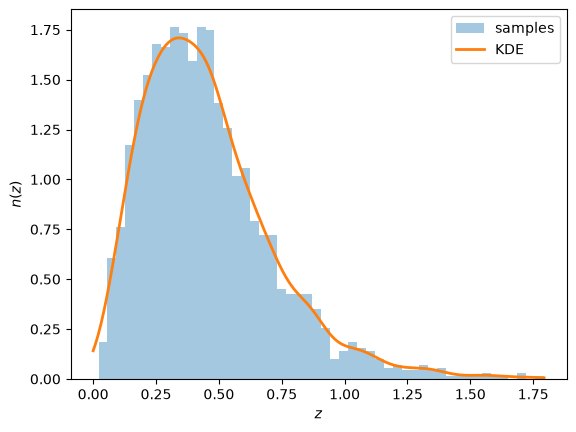

In [10]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
z = rng.gamma(shape=3.0, scale=0.15, size=2000)   # Smail-like n(z), z0 = 0.15

kde = gaussian_kde(z, bw_method="scott")          # "silverman" or a float also work
zgrid = np.linspace(0, z.max(), 500)

plt.hist(z, bins=50, density=True, alpha=0.4, label="samples")
plt.plot(zgrid, kde(zgrid), lw=2, label="KDE")
plt.xlabel(r"$z$"); plt.ylabel(r"$n(z)$"); plt.legend()
plt.show()

In [13]:
import numpy as np
from KDEpy import TreeKDE   # pip install KDEpy

sigma = 0.03 * (1 + z)                                   # per-object σ
zgrid = np.linspace(0, z.max() + 3 * sigma.max(), 500)
dens  = TreeKDE(kernel="gaussian", bw=sigma).fit(z).evaluate(zgrid)

In [18]:
def plot_kde(z, dens, kde, zgrid):
    plt.hist(z, bins=50, density=True, alpha=0.4, label="samples")
    plt.plot(zgrid, kde(zgrid), lw=2, label="KDE scipy")
    plt.plot(zgrid, dens, lw=2, label="KDE kdepy")
    plt.xlabel(r"$z$"); plt.ylabel(r"$n(z)$")
    plt.legend()
    plt.show()

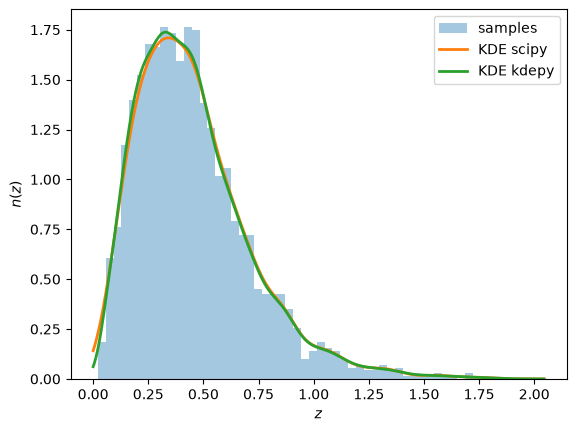

In [21]:
plot_kde(z, dens, kde, zgrid)